In [ ]:
## Artificial Neural Network

In [ ]:
#!pip install tensorflow

In [1]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [2]:
## Importing basic libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [4]:
dataset = pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
## Divide the dataset into dependent and independent features

X = dataset.iloc[:,3:13]
y = dataset.iloc[:,13]

In [6]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [8]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [9]:
## Feature Engineering
geography = pd.get_dummies(X['Geography'],drop_first=True, dtype=int)
gender = pd.get_dummies(X['Gender'],drop_first=True, dtype=int)

In [10]:
## Concatinate the variables with dataset
X.drop(['Geography', 'Gender'],axis=1,inplace=True)

In [11]:
X.head(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58


In [12]:
X=pd.concat([X,geography,gender], axis=1)

In [13]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [14]:
## Spliting the dataset into Train and Test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [15]:
## Feature Scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [16]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [17]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [18]:
X_train.shape

(8000, 11)

In [42]:
## Tensorflow open source library Keras is a wrapper by google / Pytorch is by facebook
## Create the ANN
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU
from tensorflow.keras.layers import Dropout

In [43]:
 ### Initialize the ANN
classifier = Sequential()

In [44]:
### Adding the input layer
classifier.add(Dense(units=11, activation='relu'))

In [45]:
### Adding first hidden layer
classifier.add(Dense(units=7, activation='relu'))
classifier.add(Dropout(0.3))

In [46]:
### Adding Second hidden layer
classifier.add(Dense(units=6, activation='relu'))

In [47]:
### Adding the output layer
classifier.add(Dense(1,activation='sigmoid'))

In [48]:
## Adam optimizer by default take learning rate as 0.01, but if you want to define own learnig rate we can set it

opt =tf.keras.optimizers.Adam(learning_rate=0.01)

In [49]:
classifier.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [50]:
## Early stopping : When the accuracy not increasing it automatically stops training

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

In [51]:
model_history = classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8102 - loss: 0.4485 - val_accuracy: 0.8489 - val_loss: 0.3799
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8395 - loss: 0.3887 - val_accuracy: 0.8429 - val_loss: 0.3773
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8412 - loss: 0.3775 - val_accuracy: 0.8497 - val_loss: 0.3712
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8442 - loss: 0.3679 - val_accuracy: 0.8516 - val_loss: 0.3671
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8533 - loss: 0.3645 - val_accuracy: 0.8429 - val_loss: 0.3768
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8485 - loss: 0.3621 - val_accuracy: 0.8519 - val_loss: 0.3720
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8520 - loss: 0.3599 - val_accuracy: 0.8466 - val_loss: 0.3637
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8522 - loss: 0.3598 - 

In [52]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

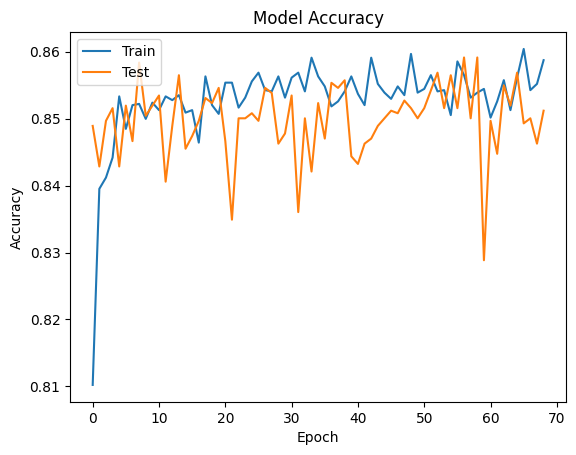

In [53]:
## Summerizing history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

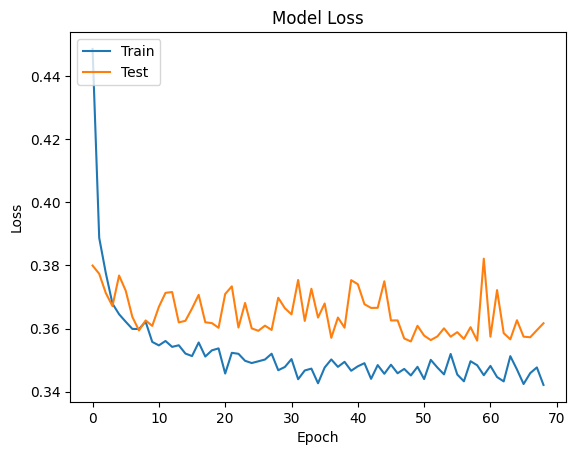

In [54]:
## Summerizing history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [55]:
## Making the predictions and Evaluating the Model
# Predicting test set results

y_pred = classifier.predict(X_test)
y_pred = (y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [39]:
## Make Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1496,   99],
       [ 183,  222]])

In [56]:
## Calculating the accuracy
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)
score

0.861

In [57]:
## Get the weights
classifier.get_weights()

[array([[ 3.58967721e-01, -6.89730883e-01,  1.27258688e-01,
          1.14657950e+00,  5.27019240e-02,  2.08731666e-02,
          5.02476394e-01, -1.08718611e-01,  1.74985379e-01,
          3.35711658e-01,  3.26201469e-01],
        [-3.18736410e+00, -1.95139563e+00, -5.79898469e-02,
         -1.48664728e-01,  1.76950061e+00,  3.17478871e+00,
         -3.21607852e+00,  1.01642823e+00, -3.51454115e+00,
         -1.73150122e+00, -2.31619024e+00],
        [-2.54237235e-01,  1.44123185e+00,  1.46043926e-01,
         -3.47470701e-01,  1.86202396e-02,  3.68604183e-01,
          9.97394025e-01,  1.45639196e-01, -1.33676425e-01,
         -1.63483894e+00,  5.49830198e-01],
        [ 1.01310611e-01,  4.52734977e-02,  2.49038681e-01,
         -2.31478357e+00, -1.76524270e+00, -4.82980674e-03,
         -2.06720901e+00,  6.55664444e-01,  2.12372327e+00,
          1.75479209e+00, -3.72068137e-01],
        [ 1.48273051e+00,  1.50421417e+00, -2.30691675e-02,
          1.32926893e+00, -5.18685007e+00,  